<a href="https://colab.research.google.com/github/satani99/triton_kernels/blob/main/profiling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch

In [2]:
a = torch.tensor([1., 2., 3.])

In [3]:
print(torch.square(a))
print(a ** 2)
print(a * a)

tensor([1., 4., 9.])
tensor([1., 4., 9.])
tensor([1., 4., 9.])


In [4]:
def time_pytorch_function(func, input):
  start = torch.cuda.Event(enable_timing=True)
  end = torch.cuda.Event(enable_timing=True)

  for _ in range(5):
    func(input)

  start.record()
  func(input)
  end.record()
  torch.cuda.synchronize()
  return start.elapsed_time(end)

In [5]:
b = torch.randn(10000, 10000).cuda()

In [6]:
def square_2(a):
  return a * a

In [7]:
def square_3(a):
  return a ** 2

In [8]:
time_pytorch_function(torch.square, b)


3.3447039127349854

In [9]:
time_pytorch_function(square_2, b)


3.3423359394073486

In [10]:
time_pytorch_function(square_3, b)

3.3441920280456543

In [11]:
print("============")
print("Profiling torch.square")
print("============")

with torch.profiler.profile() as prof:
  torch.square(b)

print(prof.key_averages().table(sort_by="cuda_time_total", row_limit=10))

Profiling torch.square
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg     Self CUDA   Self CUDA %    CUDA total  CUDA time avg    # of Calls  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                           aten::square         0.59%      36.286us        48.31%       2.986ms       2.986ms       0.000us         0.00%       6.653ms       6.653ms             1  
                                              aten::pow         2.05%     126.390us        47.73%       2.949ms       2.949ms       3.326ms       100.00%       6.653ms       6.653ms   

/usr/local/lib/python3.12/dist-packages/torch/profiler/profiler.py:217: UserWarning: Warning: Profiler clears events at the end of each cycle.Only events from the current cycle will be reported.To keep events across cycles, set acc_events=True.
  _warn_once(


In [12]:
print("============")
print("Profiling a * a")
print("============")

with torch.profiler.profile() as prof:
  square_2(b)

print(prof.key_averages().table(sort_by="cuda_time_total", row_limit=10))

Profiling a * a
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg     Self CUDA   Self CUDA %    CUDA total  CUDA time avg    # of Calls  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                              aten::mul         1.74%     106.359us        46.70%       2.849ms       2.849ms       3.341ms       100.00%       6.681ms       6.681ms             1  
                                Activity Buffer Request        44.30%       2.703ms        44.30%       2.703ms       2.703ms       3.341ms       100.00%       3.341ms       3.341ms          

In [13]:
print("===========")
print("Profiling a ** 2")
print("===========")

with torch.profiler.profile() as prof:
  square_3(b)

print(prof.key_averages().table(sort_by="cuda_time_total", row_limit=10))

Profiling a ** 2
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg     Self CUDA   Self CUDA %    CUDA total  CUDA time avg    # of Calls  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                              aten::pow         1.73%     107.087us        47.51%       2.936ms       2.936ms       3.344ms       100.00%       6.689ms       6.689ms             1  
                                Activity Buffer Request        45.17%       2.792ms        45.17%       2.792ms       2.792ms       3.344ms       100.00%       3.344ms       3.344ms         

In [15]:
import triton
import triton.language as tl
import torch

In [18]:
import os
os.environ["TRIRON_INTERPRET"] = "1"

In [19]:
@triton.jit
def square_kernel(output_ptr, input_ptr, input_row_stride, output_row_stride, n_cols, BLOCK_SIZE: tl.constexpr):
  row_idx = tl.program_id(0)

  row_start_ptr = input_ptr + row_idx * input_row_stride

  col_offsets = tl.arange(0, BLOCK_SIZE)
  input_ptrs = row_start_ptr + col_offsets

  row = tl.load(input_ptrs,mask=col_offsets < n_cols, other=-float('inf'))

  square_output = row * row

  output_row_start_ptr = output_ptr + row_idx * output_row_stride
  output_ptrs = output_row_start_ptr + col_offsets
  tl.store(output_ptrs, square_output,mask=col_offsets < n_cols)

In [26]:
def square(x):
  n_rows, n_cols = x.shape

  BLOCK_SIZE = triton.next_power_of_2(n_cols)

  num_warps = 4
  if BLOCK_SIZE >+ 2048:
    num_warps = 8
  if BLOCK_SIZE >= 4096:
    num_warps = 16

  y = torch.empty_like(x)

  square_kernel[(n_rows, )](
      y,
      x,
      x.stride(0),
      y.stride(0),
      n_cols,
      num_warps=num_warps,
      BLOCK_SIZE=BLOCK_SIZE,
  )
  return y

In [28]:

torch.manual_seed(42)
x = torch.randn(1823, 781, device="cuda")
y_triton = square(x)
y_torch = torch.square(x)
assert torch.allclose(y_triton, y_torch), (y_triton, y_torch)

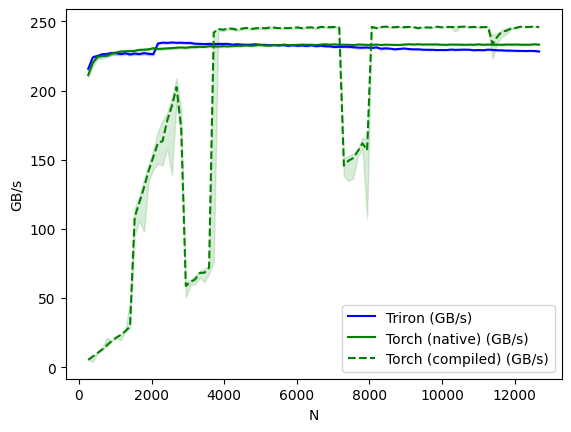

square() performance:
          N  Triron (GB/s)  Torch (native) (GB/s)  Torch (compiled) (GB/s)
0     256.0     215.756379             211.236097                 5.355889
1     384.0     224.054704             219.980980                 7.721776
2     512.0     225.016305             224.438347                10.243201
3     640.0     226.220232             225.093590                12.811761
4     768.0     226.409104             225.145144                15.833298
5     896.0     227.217447             226.656121                18.704341
6    1024.0     227.062809             227.506187                21.312087
7    1152.0     226.376517             228.260072                23.327262
8    1280.0     227.003803             228.447929                26.093327
9    1408.0     226.092524             228.529408                29.456488
10   1536.0     226.800859             228.746939               108.548240
11   1664.0     226.376517             229.439976               118.965022
12 

In [41]:
@triton.testing.perf_report(
    triton.testing.Benchmark(
        x_names=['N'],
        x_vals=[128 * i for i in range(2, 100)],
        line_arg='provider',
        line_vals=[
            'triton',
            'torch-native',
            'torch-compile'
        ],
        line_names=[
            "Triron",
            "Torch (native)",
            "Torch (compiled)"
        ],
        styles=[('blue', '-'), ('green', '-'), ('green', '--')],
        ylabel="GB/s",
        plot_name="square() performance",
        args={'M': 4096}
    )
)

def benchmark(M, N, provider):
  x = torch.randn(M, N, device="cuda", dtype=torch.float32)
  quantiles = [0.5, 0.2, 0.8]
  if provider == 'torch-native':
    ms, min_ms, max_ms = triton.testing.do_bench(lambda: torch.square(x), quantiles=quantiles)
  if provider == "triton":
    ms, min_ms, max_ms = triton.testing.do_bench(lambda: square(x), quantiles=quantiles)
  if provider == "torch-compile":
    ms, min_ms, max_ms = triton.testing.do_bench(lambda: torch.compile(torch.square)(x), quantiles=quantiles)
  gbps = lambda ms: 2 * x.nelement() * x.element_size() * 1e-9 / (ms * 1e-3)
  return gbps(ms), gbps(max_ms), gbps(min_ms)

benchmark.run(show_plots=True, print_data=True, save_path='')

